The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
FDM del Calor guardado.
Error L2 relativo en t=T: 0.00032472971643222214
Estabilidad: 0.25


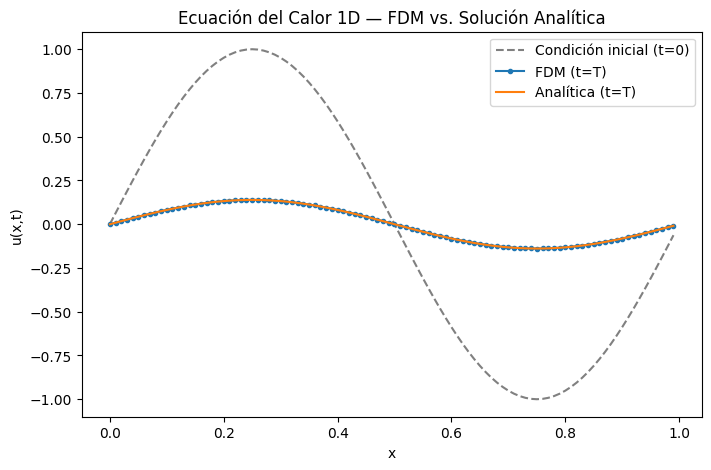

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from config import MU_HEAT, NX_HEAT, NT_HEAT, L_HEAT, T_HEAT, ALPHA

def construir_matriz_A(nx, mu):
    """
    Construye la matriz de propagación A (tridiagonal periódica)
    para el esquema explícito de la ecuación del calor.
    u^{n+1} = A @ u^n
    """
    A = np.zeros((nx, nx))

    for i in range(nx):
        A[i, i] = 1 - 2 * mu                
        A[i, (i + 1) % nx] += mu             
        A[i, (i - 1) % nx] += mu             

    return A

A = construir_matriz_A(NX_HEAT, MU_HEAT)


# Condición inicial
x = np.linspace(0, L_HEAT, NX_HEAT, endpoint=False)   # nodos espaciales sin incluir el último (periodicidad)
u0 = np.sin(2 * np.pi * x / L_HEAT)

# Bucle de evolución temporal
U = np.zeros((NT_HEAT + 1, NX_HEAT))   # Cada fila e esta matriz guarda los valores de cada paso en t
U[0] = u0

for n in range(NT_HEAT):
    U[n + 1] = A @ U[n]

# Comparación con la solución analítica
def solucion_analitica(x, t, alpha, L):
    return np.exp(-alpha * (2 * np.pi / L)**2 * t) * np.sin(2 * np.pi * x / L)

u_exacta_final = solucion_analitica(x, T_HEAT, ALPHA, L_HEAT)
u_fdm_final = U[-1]

np.savez('heat_fdm_resultado.npz', x=x, u_fdm_final=u_fdm_final, u_exacta=u_exacta_final)
print("FDM del Calor guardado.")

# Cálculo del error
error_l2 = np.linalg.norm(u_fdm_final - u_exacta_final) / np.linalg.norm(u_exacta_final)
print("Error L2 relativo en t=T:", error_l2)
print(f"Estabilidad: {MU_HEAT}")

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(x, u0, '--', label='Condición inicial (t=0)', color='gray')
plt.plot(x, u_fdm_final, 'o-', label='FDM (t=T)', markersize=3)
plt.plot(x, u_exacta_final, '-', label='Analítica (t=T)')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title('Ecuación del Calor 1D — FDM vs. Solución Analítica')
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
FDM del Calor guardado.
Error L2 relativo en t=T: 1.0761871981312655e+106
Estabilidad: 0.5995203836930455


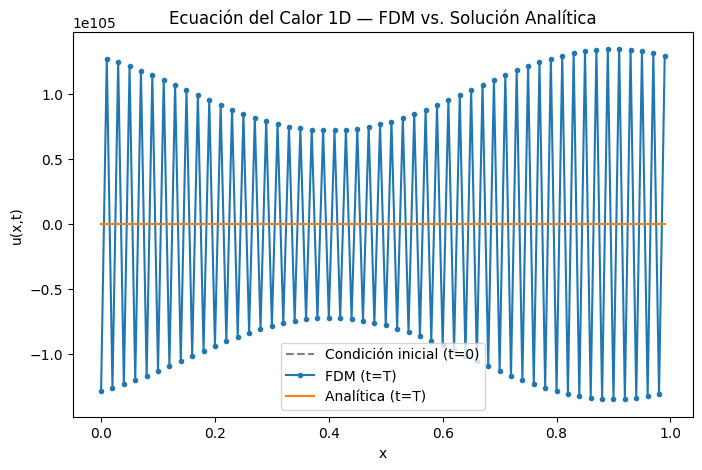

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from config import NX_HEAT, L_HEAT, T_HEAT, ALPHA

NT_HEAT= 834
DX_HEAT = L_HEAT / NX_HEAT
DT_HEAT = T_HEAT / NT_HEAT
MU_HEAT = ALPHA * DT_HEAT / DX_HEAT**2

def construir_matriz_A(nx, mu):
    """
    Construye la matriz de propagación A (tridiagonal periódica)
    para el esquema explícito de la ecuación del calor.
    u^{n+1} = A @ u^n
    """
    A = np.zeros((nx, nx))

    for i in range(nx):
        A[i, i] = 1 - 2 * mu                
        A[i, (i + 1) % nx] += mu             
        A[i, (i - 1) % nx] += mu             

    return A

A = construir_matriz_A(NX_HEAT, MU_HEAT)


# Condición inicial
x = np.linspace(0, L_HEAT, NX_HEAT, endpoint=False)   # nodos espaciales sin incluir el último (periodicidad)
u0 = np.sin(2 * np.pi * x / L_HEAT)

# Bucle de evolución temporal
U = np.zeros((NT_HEAT + 1, NX_HEAT))   # Cada fila e esta matriz guarda los valores de cada paso en t
U[0] = u0

for n in range(NT_HEAT):
    U[n + 1] = A @ U[n]

# Comparación con la solución analítica
def solucion_analitica(x, t, alpha, L):
    return np.exp(-alpha * (2 * np.pi / L)**2 * t) * np.sin(2 * np.pi * x / L)

u_exacta_final = solucion_analitica(x, T_HEAT, ALPHA, L_HEAT)
u_fdm_final = U[-1]

np.savez('heat_fdm_resultado_inestable.npz', x=x, u_fdm_final=u_fdm_final, u_exacta=u_exacta_final)
print("FDM del Calor guardado.")

# Cálculo del error
error_l2 = np.linalg.norm(u_fdm_final - u_exacta_final) / np.linalg.norm(u_exacta_final)
print("Error L2 relativo en t=T:", error_l2)
print(f"Estabilidad: {MU_HEAT}")

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(x, u0, '--', label='Condición inicial (t=0)', color='gray')
plt.plot(x, u_fdm_final, 'o-', label='FDM (t=T)', markersize=3)
plt.plot(x, u_exacta_final, '-', label='Analítica (t=T)')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title('Ecuación del Calor 1D — FDM vs. Solución Analítica')
plt.show()
